# non-LFP models as comparison


doing some visualization while testing how best to train the LFP bandpower-matched models


- Here, set the target LFP signal to 1 for the entire trial, rather than just during maintenance

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

## single model, no jitter

### load model

In [2]:
model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_25_140435.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [3]:
for keys in mat_data.keys():
    print(keys)

__header__
__version__
__globals__
x0
r0
w0
taus_gaus0
w_in0
u
o
w
x
target
lfp_power_target
epsp
w_out
r
m
som_m
N
exc
inh
w_in
b_out
som_N
losses
losses_out
losses_lfp
taus
eval_perf_mean
eval_loss_mean
eval_os
eval_labels
taus_gaus
tr
activation
opt_scaling_factor


In [4]:
mat_data['tr']

array([[34001]])

In [5]:
mat_data['eval_perf_mean']

array([[1.]])

(2, 300)


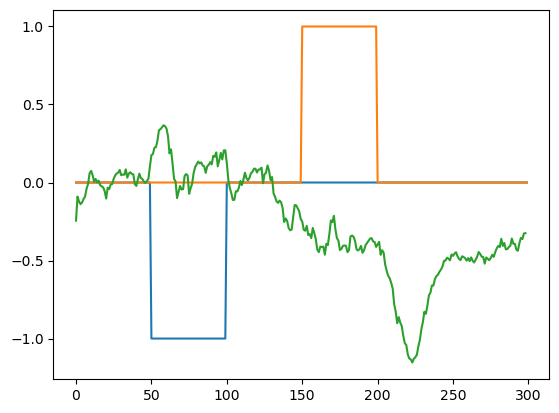

[]
[150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]


In [6]:
print(mat_data['u'].shape)
plt.plot(mat_data['u'].T)
plt.plot(np.squeeze(mat_data['o']))
plt.show()
print(np.where(mat_data['u'][0,:] > 0)[0])
print(np.where(mat_data['u'][1,:] > 0)[0])

### training loss

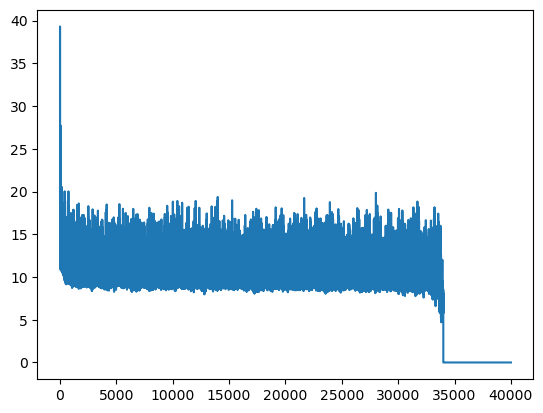

In [7]:
plt.plot(mat_data['losses'].T)
plt.show()

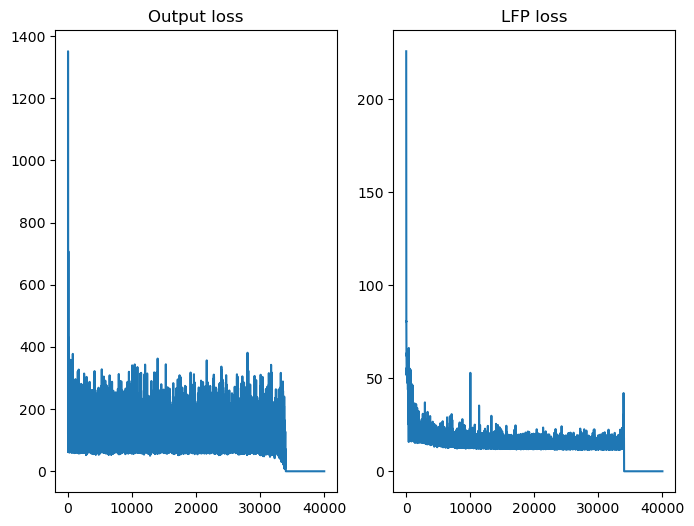

In [8]:
fig, axs = plt.subplots(1,2, figsize=(8,6))
axs[0].plot(mat_data['losses_out'].T)
axs[0].set_title('Output loss')
axs[1].plot(mat_data['losses_lfp'].T)
axs[1].set_title('LFP loss')
plt.show()

In [9]:
mat_data['x'].shape

(300, 200, 1)

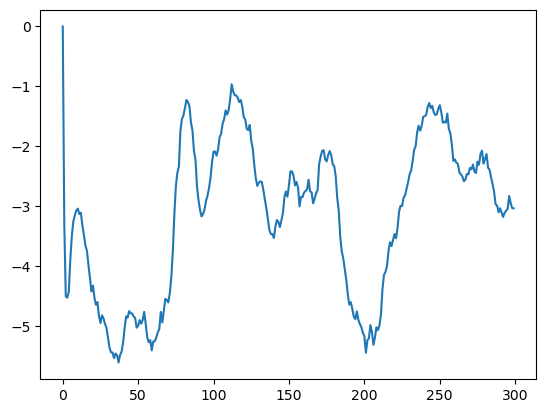

In [10]:
plt.plot(mat_data['x'][:,0,0].T)
plt.show()

### Visualize outputs

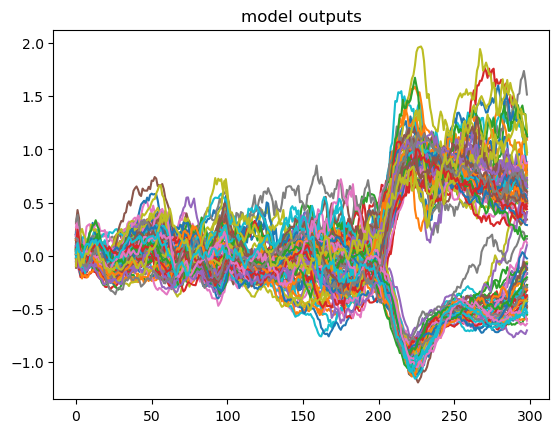

In [11]:
plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
plt.title('model outputs')
plt.show()

### plot spect lol

(300, 1)


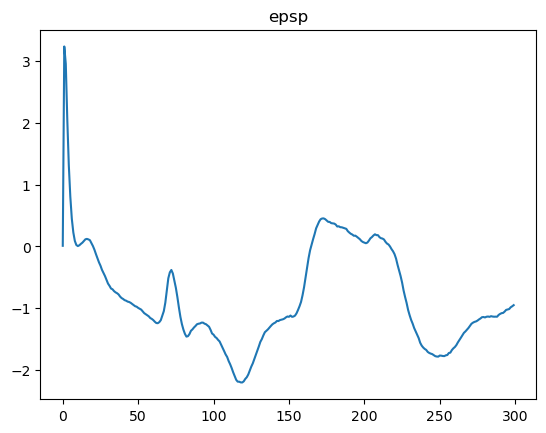

In [12]:
epsp = mat_data['epsp']
print(epsp.shape)
plt.plot(epsp)
plt.title('epsp');

In [24]:
settings = {
            'T': 300, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 50, # input stim duration (in steps)
            'delay': 50, # delay b/w the two stimuli (in steps)
            'DeltaT': 1, # sampling rate
            'fs': 200, # sampling rate (Hz)
            'taus': [4, 25], # decay time-constants (in steps)
            'lfp_power_target': [4, 8], # target power for the LFP
            'task': 'xor', # task name
            }

In [14]:
mat_data['lfp_power_target']

array([[4., 8.]])

2025-08-25 15:23:05.423985: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-25 15:23:05.430759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-25 15:23:05.438233: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-25 15:23:05.440296: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-25 15:23:05.447028: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term
(300,)


2025-08-25 15:23:06.484209: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-08-25 15:23:06.500768: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled


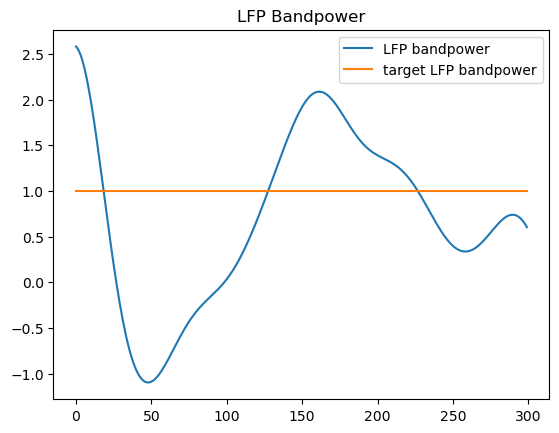

In [15]:
# plot bandpower

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import calculate_LFP_bandpower, generate_target_LFP_bandpower

bandpower = calculate_LFP_bandpower(settings, epsp)
import tensorflow.compat.v1 as tf
with tf.Session() as sess:
    lfp_bandpower = sess.run(bandpower)
print(lfp_bandpower.shape)
y = generate_target_LFP_bandpower(settings)

plt.figure()
plt.plot(lfp_bandpower, label='LFP bandpower')
plt.plot(y, label='target LFP bandpower')
plt.legend()
plt.title('LFP Bandpower');

In [25]:
# ---- settings ----
T         = settings['T']
fs        = settings['fs']           # Hz
dt        = 1.0 / fs
fmin, fmax = 4.0, 100.0
num_freqs = 40
band_lo, band_hi = settings['lfp_power_target']  # e.g., [30, 80]
stim_on   = settings['stim_on']

# ---- epsp -> shape [1, T, 1] ----
# epsp is length T, each element shape [1,1], so squeeze & stack:
# pdb.set_trace()
epsp_vec = tf.squeeze(tf.stack(epsp, axis=0))          # [T] or [T,] float32
epsp_sig = tf.reshape(epsp_vec, [1, T, 1])                   # [batch=1, time=T, ch=1]

# ---- frequencies & scales ----
freqs = tf.exp(tf.linspace(tf.log(fmin), tf.log(fmax), num_freqs))  # [num_freqs]
# Morlet central frequency for PyWavelets 'morl' ~ 0.8125, but we can treat as hyperparam.
# Match PyWavelets by using that same fc:
fc = tf.constant(0.8125, dtype=tf.float32)
scales = fc / (freqs * dt)                                   # [num_freqs]

# ---- build Morlet kernels (real & imag) ----
# Window length: K cycles of the center frequency at each scale.
# K=6 is a common choice. Use time support symmetric around 0.
K = 6.0
# For a Morlet at frequency f, approximate sigma_t ~ K/(2*pi*f)
# Use a *shared* max half-width across freqs for "same" padding kernels.
# Choose a kernel that covers the lowest freq sufficiently:
f_low = fmin
sigma_t_low = K / (2.0 * np.pi * f_low)
half_width_sec = 4.0 * sigma_t_low   # ~±4 sigma
kernel_len = tf.cast(tf.round(2.0 * half_width_sec * fs) + 1, tf.int32)  # odd length
kernel_len = tf.maximum(kernel_len, 31)  # avoid too-short kernels
# time vector centered at 0
t_idx = tf.range(kernel_len, dtype=tf.float32) - tf.cast(kernel_len - 1, tf.float32)/2.0
t_sec = t_idx / fs  # [L]

# Morlet wavelet (complex): psi(t; f) = A * exp(-t^2/(2*sigma^2)) * exp(2j*pi*f*t)
# We normalize each kernel to unit L2 energy so power is comparable across freqs.
# Build per-frequency kernels (broadcast over [L, num_freqs]).
two_pi = tf.constant(2.0*np.pi, tf.float32)
# sigma_t per frequency (vector) — wider at low freq:
sigma_t = K / (two_pi * freqs)  # [num_freqs]
# Gaussian envelope
env = tf.exp(-0.5 * tf.square(tf.expand_dims(t_sec,1) / tf.expand_dims(sigma_t,0)))  # [L, F]
# carrier
phase = two_pi * tf.expand_dims(t_sec,1) * tf.expand_dims(freqs,0)                   # [L, F]
cos_part = env * tf.cos(phase)                                                       # [L, F]
sin_part = env * tf.sin(phase)                                                       # [L, F]

# L2 normalize each frequency kernel
eps = 1e-8
norm = tf.sqrt(tf.reduce_sum(tf.square(cos_part) + tf.square(sin_part), axis=0, keepdims=True) + eps)  # [1,F]
cos_part = cos_part / norm
sin_part = sin_part / norm

# conv1d wants [filter_width, in_channels, out_channels]
# in_channels=1; out_channels=F (one filter per frequency)
cos_filt = tf.expand_dims(cos_part, 1)  # [L,1,F]
sin_filt = tf.expand_dims(sin_part, 1)  # [L,1,F]

# ---- convolution: "SAME" to keep T ----
real_coeff = tf.nn.conv1d(epsp_sig, cos_filt, stride=1, padding='SAME')  # [1,T,F]
imag_coeff = tf.nn.conv1d(epsp_sig, sin_filt, stride=1, padding='SAME')  # [1,T,F]

power = tf.square(real_coeff) + tf.square(imag_coeff)  # [1,T,F]
power = tf.squeeze(power, axis=0)                      # [T,F]

# ---- select target band & average across freqs in band ----
band_mask = tf.logical_and(freqs >= band_lo, freqs <= band_hi)         # [F]
band_mask_f = tf.cast(band_mask, tf.float32)
# Avoid empty band:
denom = tf.maximum(tf.reduce_sum(band_mask_f), 1.0)
band_power = tf.tensordot(power, band_mask_f/denom, axes=[[1],[0]])    # [T]

# ---- baseline z-score (pure TF) ----
# baseline: e.g., indices 10 : stim_on (exclusive)
start = tf.constant(10, dtype=tf.int32)
stop  = tf.cast(stim_on, tf.int32)
base_slice = band_power[start:stop]                                     # [stop-start]
base_mean  = tf.reduce_mean(base_slice)
base_std   = tf.math.reduce_std(base_slice) + 1e-8
lfp_power_z = (band_power - base_mean) / base_std                       # [T]



In [26]:
with tf.Session() as sess:
    power, freqs = sess.run([power, freqs])

In [27]:
print(power.shape, freqs.shape)

(300, 40) (40,)


In [28]:
freqs

array([  4.       ,   4.3441477,   4.717905 ,   5.1238194,   5.564657 ,
         6.0434237,   6.5633826,   7.128076 ,   7.741353 ,   8.407395 ,
         9.130743 ,   9.9163265,  10.769497 ,  11.696072 ,  12.702367 ,
        13.795239 ,  14.982141 ,  16.271158 ,  17.67108  ,  19.191446 ,
        20.84262  ,  22.635862 ,  24.583382 ,  26.698462 ,  28.995518 ,
        31.490204 ,  34.199524 ,  37.14195  ,  40.337532 ,  43.80805  ,
        47.57716  ,  51.670555 ,  56.116135 ,  60.944195 ,  66.18765  ,
        71.88223  ,  78.066765 ,  84.783394 ,  92.0779   , 100.00001  ],
      dtype=float32)

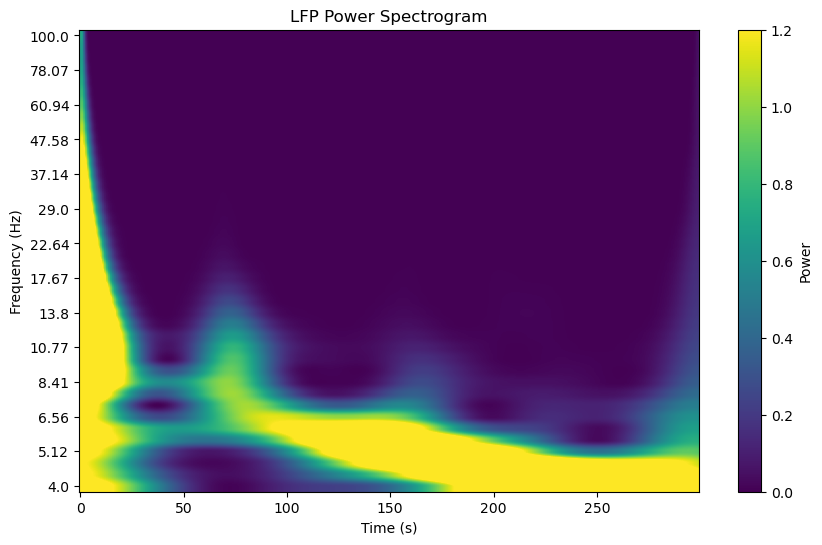

In [29]:
# plot power as spectrogram

time_cutoff = 25

plt.figure(figsize=(10, 6))
# plt.imshow(power[time_cutoff:,:].T, aspect='auto', extent=[time_cutoff, T, fmin, fmax], origin='lower',
#            vmin=0, vmax=1.2)
plt.imshow(power.T, aspect='auto', origin='lower',
           vmin=0, vmax=1.2)
# plt.axhline(y=band_lo, color='r', linestyle='--', label='Band low')
# plt.axhline(y=band_hi, color='r', linestyle='--', label='Band high')
plt.yticks()
plt.yticks(np.arange(0, num_freqs, 3), np.round(freqs[::3], 2))
plt.colorbar(label='Power')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('LFP Power Spectrogram')
plt.show()

### get final variables

In [16]:
w = mat_data['w']
m = mat_data['m']
final_w = np.matmul(w, m)
taus_gaus = mat_data['taus_gaus']
taus = mat_data['taus'].flatten()
taus_sig = (1/(1+np.exp(-taus_gaus))*(taus[1] - taus[0])) + taus[0]

In [17]:
exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[  0   3  13  23  24  25  26  28  31  32  35  40  45  55  70  71  72  84
  85  88  89  94  95  98 100 103 106 107 109 110 111 112 114 116 122 124
 126 133 135 139 157 161 179 191 192 193 194]


### model eval

In [18]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model
from model import generate_input_stim_xor

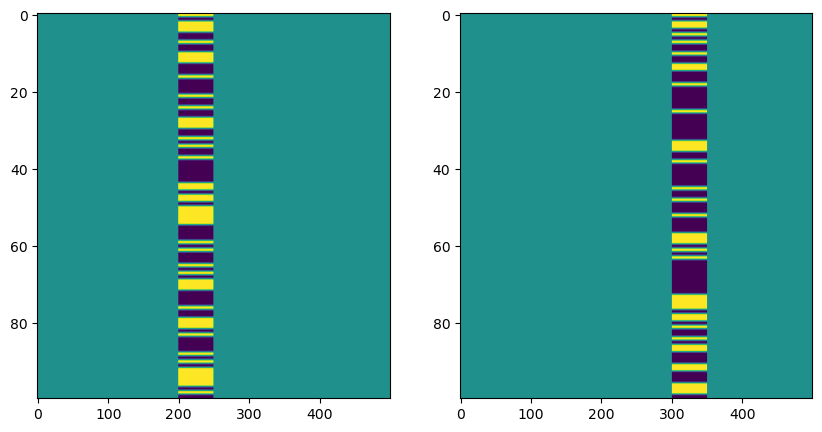

In [19]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }
inputs = np.zeros((100, 2, settings['T']))
for i in range(100):
    u, label = generate_input_stim_xor(settings)
    inputs[i, :, :] = u
# Plotting the generated trials
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(inputs[:, 0, :], aspect='auto')
axs[1].imshow(inputs[:, 1, :], aspect='auto')
plt.show()

(200, 500)
(200, 500)
(500,)


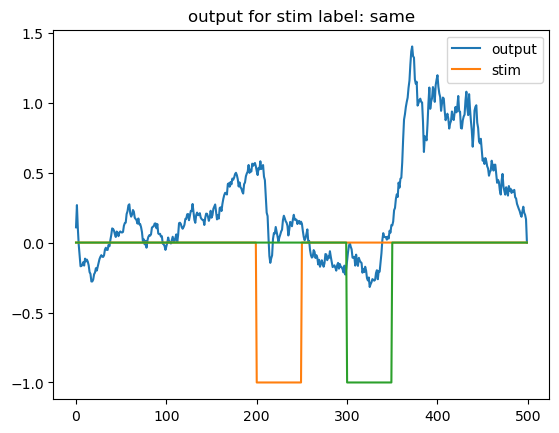

In [20]:
import importlib
importlib.reload(model)

x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u)
print(x.shape)
print(r.shape)
print(o.shape)

plt.figure()
plt.plot(o)
plt.plot(u[0,:])
plt.plot(u[1,:])
plt.title(f'output for stim label: {label}')
plt.legend(['output','stim'])
plt.show()

In [21]:
# model eval on 100 random trials

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
eval_perf = np.zeros(n_trials)
eval_os = np.zeros((n_trials, settings['T']))

for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_xor(settings)
    _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=eval_u)
    eval_os[i, :] = np.squeeze(eval_o)
    if eval_label == 'same':
        if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
            eval_perf[i] = 1
    else:
        if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
            eval_perf[i] = 1

eval_perf_mean = np.nanmean(eval_perf)
print("Performance: %.2f"%(eval_perf_mean))

Performance: 0.99


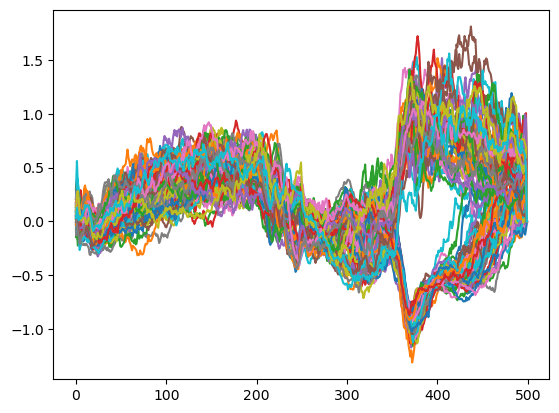

In [22]:
plt.figure()
plt.plot(eval_os.T)
plt.show()

### Trajectory plots

In [29]:

from sklearn.decomposition import PCA


In [31]:
r = mat_data['r']
r = np.squeeze(r)
r.shape

(300, 200)

X (r): time x neurons  

U: time x n_components  

S: n_components  

Vt: n_components x neurons  

In [32]:
# X = USVt

pca = PCA(n_components=100).fit(r)
r_U = pca.transform(r)
r_S = pca.singular_values_
r_Vt = pca.components_

print(r_U.shape)
print(r_S.shape)
print(r_Vt.shape)

(300, 100)
(100,)
(100, 200)


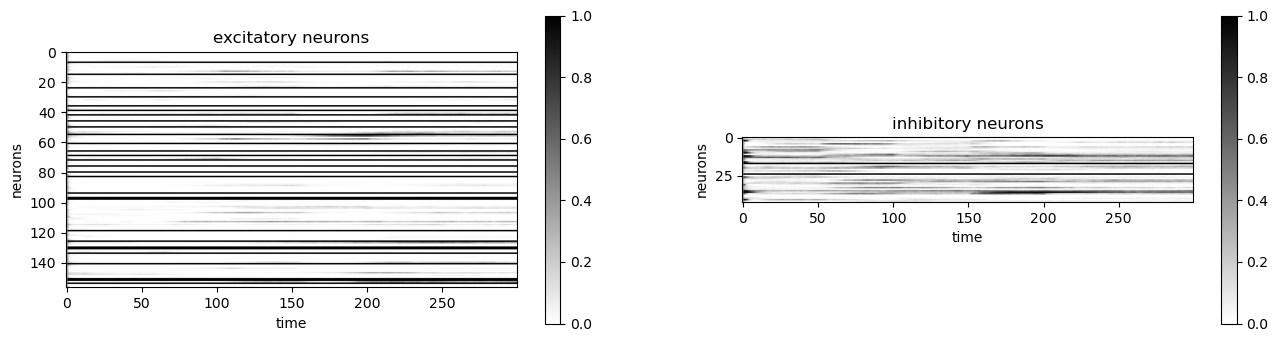

157 excitatory neurons
43 inhibitory neurons


In [33]:
fig,axs = plt.subplots(1,2,figsize=(16,4))
im1 = axs[0].imshow(r[:,exc_ind].T,cmap='binary',vmin=0, vmax=1)
axs[0].set_xlabel('time')
axs[0].set_ylabel('neurons')
axs[0].set_title('excitatory neurons')
fig.colorbar(im1)

im2 = axs[1].imshow(r[:,inh_ind].T,cmap='binary',vmin=0, vmax=1)
axs[1].set_xlabel('time')
axs[1].set_ylabel('neurons')
axs[1].set_title('inhibitory neurons')
fig.colorbar(im2)

plt.show()

print(f'{len(exc_ind)} excitatory neurons')
print(f'{len(inh_ind)} inhibitory neurons')

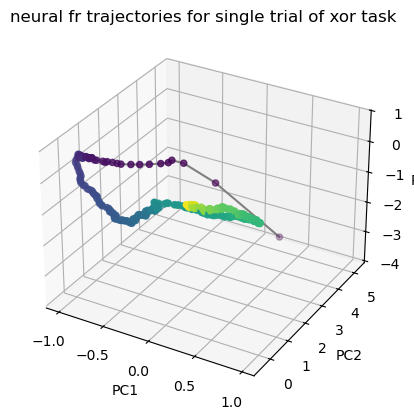

In [35]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(r_U[:,0], r_U[:,1], r_U[:,2], c=range(r_U.shape[0]))
ax.plot3D(r_U[:,0], r_U[:,1], r_U[:,2], 'gray')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('neural fr trajectories for single trial of xor task')
plt.show()

#### plot separate trajectories for multiple trials (colored by same / diff)

In [11]:
def generate_xor_type(T, stim_on, stim_dur, delay, stim1=1, stim2=-1):
     
     u = np.zeros((2, T))
     
     u[0, stim_on:stim_on+stim_dur] = stim1
     u[1, stim_on+stim_dur+delay:stim_on+2*stim_dur+delay] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

### some connectivity stuff

In [39]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_19_003814'
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'

In [41]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')

import load_data as ld 
importlib.reload(ld)

connectivity_df = ld.get_connectivity_df(model_name, 'delay',50, 
                                         all_models_dir=all_models_dir)

In [43]:
connectivity_df

,presyn_id,postsyn_id,weight,presyn_type,postsyn_type
0,0,10,0.058162,exc,exc
1,0,12,0.377221,exc,inh
2,0,29,0.419515,exc,exc
3,0,31,0.180393,exc,exc
4,0,36,0.389444,exc,exc
...,...,...,...,...,...
2409,199,49,0.237700,exc,exc
2410,199,61,0.195633,exc,exc
2411,199,102,0.204751,exc,inh
2412,199,109,0.204600,exc,exc


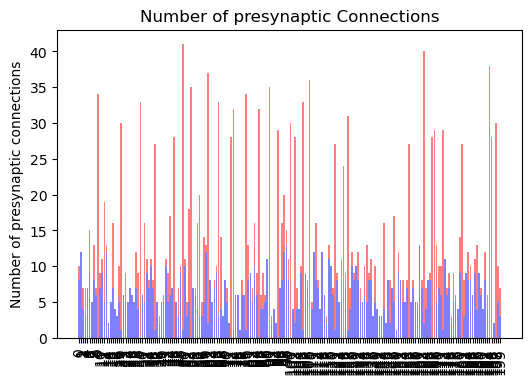

In [46]:
import connectivity_utils as cu
importlib.reload(cu)

cu.plot_num_synaptic_connections(connectivity_df, range(200), 'pre')

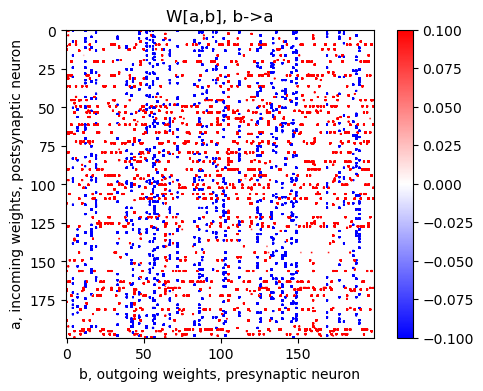

In [48]:
cu.plot_connectivity_matrix(final_w)

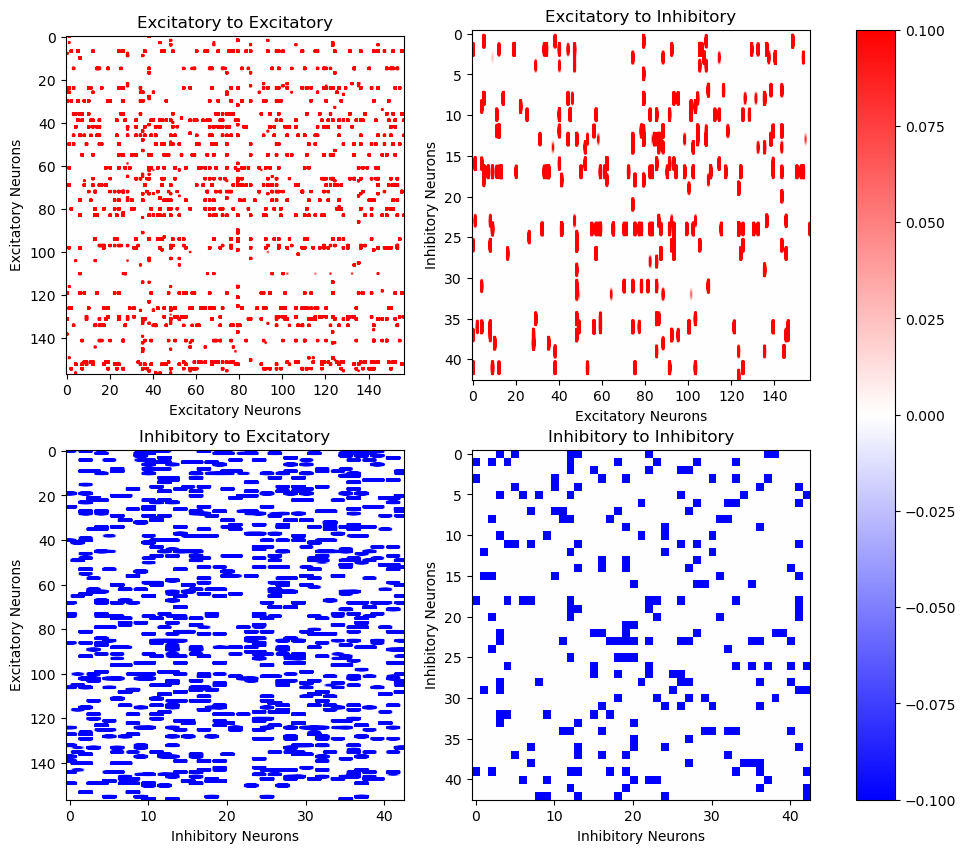

In [49]:
cu.plot_connectivity_matrix_by_type(final_w, exc_ind, inh_ind)

In [50]:
def get_num_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ii != 0), np.sum(ee != 0), np.sum(ei != 0), np.sum(ie != 0), 

def get_proportion_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ee != 0) / ee.size, np.sum(ii != 0) / ii.size, np.sum(ei != 0) / ei.size, np.sum(ie != 0) / ie.size

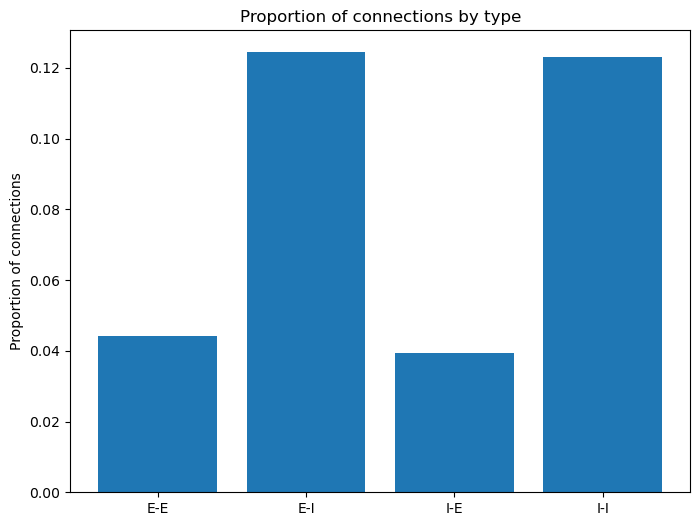

In [51]:
connect_props = get_proportion_connections(final_w, exc_ind, inh_ind)

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'E-I', 'I-E', 'I-I'], connect_props)
plt.ylabel('Proportion of connections')
plt.title('Proportion of connections by type')
plt.show()

In [ ]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import FR_RNN_dale

In [ ]:
# plot comparing trained and untrained

trained_num = []
untrained_num = []
trained_prop = []
untrained_prop = []

for model_num in range(len(model_dirs)):
    
    # trained
    W = ld.get_weights(model_dirs[model_num], condn_num, condn_phrase)
    exc_ind, inh_ind = ld.get_celltype_label(model_dirs[model_num], condn_num, condn_phrase)
    trained_num.append(get_num_connections(W, exc_ind, inh_ind))
    trained_prop.append(get_proportion_connections(W, exc_ind, inh_ind))

    # untrained
    N = 200
    net = FR_RNN_dale(N, .2, .2, np.float32(np.random.randn(N, 2)), 0, 'gaus', 1.5, True, np.float32(np.random.randn(1, N)/100))
    W_init = net.W @ net.mask
    exc_ind_init = np.where(net.exc == 1)[0]
    inh_ind_init = np.where(net.exc == 0)[0]

    untrained_num.append(get_num_connections(W_init, exc_ind_init, inh_ind_init))
    untrained_prop.append(get_proportion_connections(W_init, exc_ind_init, inh_ind_init))
# convert to numpy arrays
trained_num = np.array(trained_num)
untrained_num = np.array(untrained_num)
trained_prop = np.array(trained_prop)
untrained_prop = np.array(untrained_prop)

### neural outputs from spiking model

In [14]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import single_neuron_utils as sn

In [20]:
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'

model_name = model_fname[:-4]
model_dir = os.path.join(all_models_dir, model_name)
delay=50

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
data_files

['/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/neuraldata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/timingdata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/bhvdata_raw_delay50.mat']

In [21]:
# neural data
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True,
                                                  all_models_dir = all_models_dir)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)
times_ms, _,_ = ld.get_times_dict('ds', 'delay', 50, model_name,
                                  all_models_dir=all_models_dir)

In [22]:
print(f'Average performance for delay {delay}: {trial_perfs.mean()}')

Average performance for delay 50: 0.511


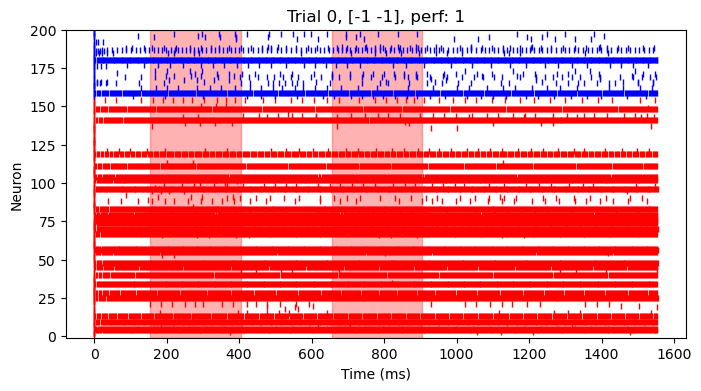

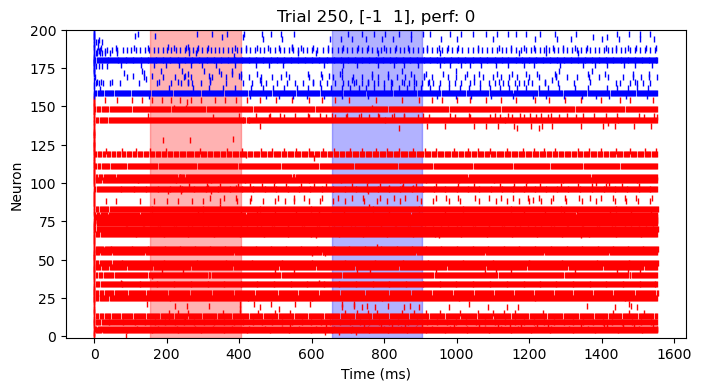

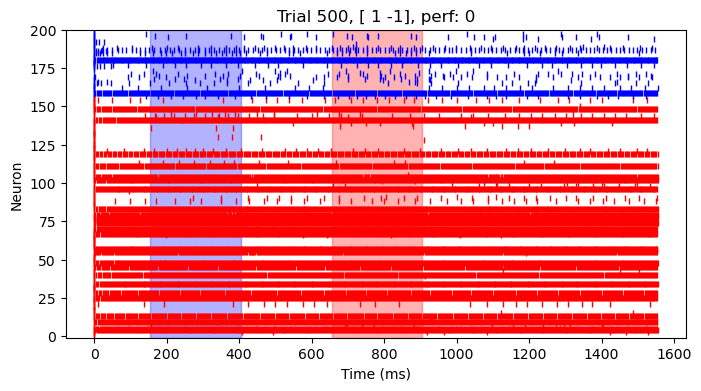

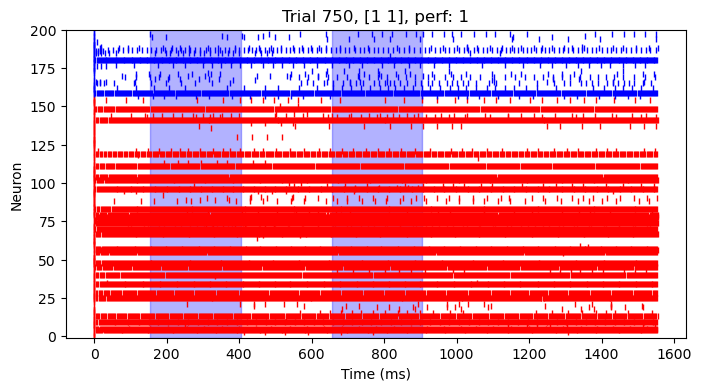

In [23]:
for trial_id in [0, 250, 500, 750]:
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]
    sn.plot_trial_raster(trial_df, 'delay', 50, all_models_dir=all_models_dir,)

## Several models with jitter

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

2025-09-12 17:25:10.211103: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-12 17:25:10.219116: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-12 17:25:10.227837: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-12 17:25:10.230495: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-12 17:25:10.237704: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# lfp models (lfp) — theta, with longer delay jitters

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', 'LFPfull_4.0_8.0', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_theta_model_list = lfp_theta_model_list[:-1]
print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

['Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_123504.mat', 'Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_124438.mat', 'Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_130954.mat', 'Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_131018.mat', 'Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_132100.mat', 'Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_135716.mat']
6
Model: Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_123504.mat, Test perf: 0.99, Train trials: 10201
Model: Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_124438.mat, Test perf: 0.99, Train trials: 17001
Model: Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_130954.mat, Test perf: 0.98, Train trials: 15501
Model: Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_131018.mat, Test perf: 1.0, Train trials: 21901
Model: Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_132100.mat, Test perf: 1.0, Train trials: 6301
Model: Task_xor_N_200_Jitter_10

In [ ]:
# remove files with <0.95 performance

import os 

def remove_files_below_threshold(model_dir, model_list, perfs, threshold=0.95):
    for i, perf in enumerate(perfs):
        if perf < threshold:
            model_path = os.path.join(model_dir, model_list[i])
            os.remove(model_path)
            print(f'Removed {model_list[i]} with performance {perf}')
    print('Done removing files.')

In [ ]:
remove_files_below_threshold(lfp_model_dir, lfp_theta_model_list, perfs, threshold=0.95)

Removed Task_xor_N_200_Jitter_10_30_LFP_4.0_8.0_2025_09_10_173223.mat with performance 0.0
Done removing files.


### generate data

In [3]:
import pickle as pk

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

Instructions for updating:
non-resource variables are not supported in the long term


In [4]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [5]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [6]:
# for LFP models

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

skipping Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_123504.mat, already saved
skipping Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_124438.mat, already saved
skipping Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_130954.mat, already saved
skipping Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_131018.mat, already saved
skipping Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_132100.mat, already saved
skipping Task_xor_N_200_Jitter_10_10_LFPfull_4.0_8.0_2025_09_12_135716.mat, already saved


### analyze generated data

Wilcoxon test statistic: 0.00, p-value: 0.03


/tmp/ipykernel_445325/3851362243.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])


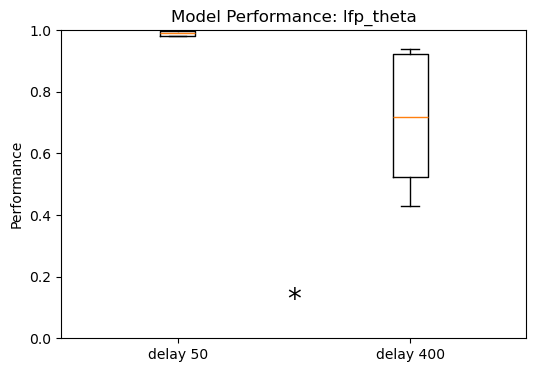

In [7]:
# performance plots, comparing delay=50 to delay=400, without lesioning

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

# create figure
fig = plt.figure(figsize=(6, 4))

perfs_delay400 = []
for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    # neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    perfs_delay400.append(np.mean(bhv_dict['perf']))
    
# plot perfs and perfs_delay400
plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])
from scipy.stats import mannwhitneyu, wilcoxon
stat, p = wilcoxon(perfs, perfs_delay400)
print("Wilcoxon test statistic: %.2f, p-value: %.2f" % (stat, p))
# stat, p = mannwhitneyu(perfs, perfs_delay400)
# print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))
if p<0.05:
    plt.text(1.5, 0.1, '*', fontsize=20, ha='center')
plt.ylabel('Performance')
plt.title(f'Model Performance: {model_list_name}')
plt.ylim([0, 1])
plt.show()

In [8]:
# spect calculation function in numpy

def compute_lfp_power_np(epsp, settings):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = settings['lfp_power_target']
    stim_on = settings['stim_on']

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]

    # --- baseline z-scoring ---
    start = 10
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


Processing model type: lfp_theta, number of models: 6


Text(0.5, 0.98, 'LFP Band Power by Correct/Incorrect, model type: lfp_theta, condn: delay400')

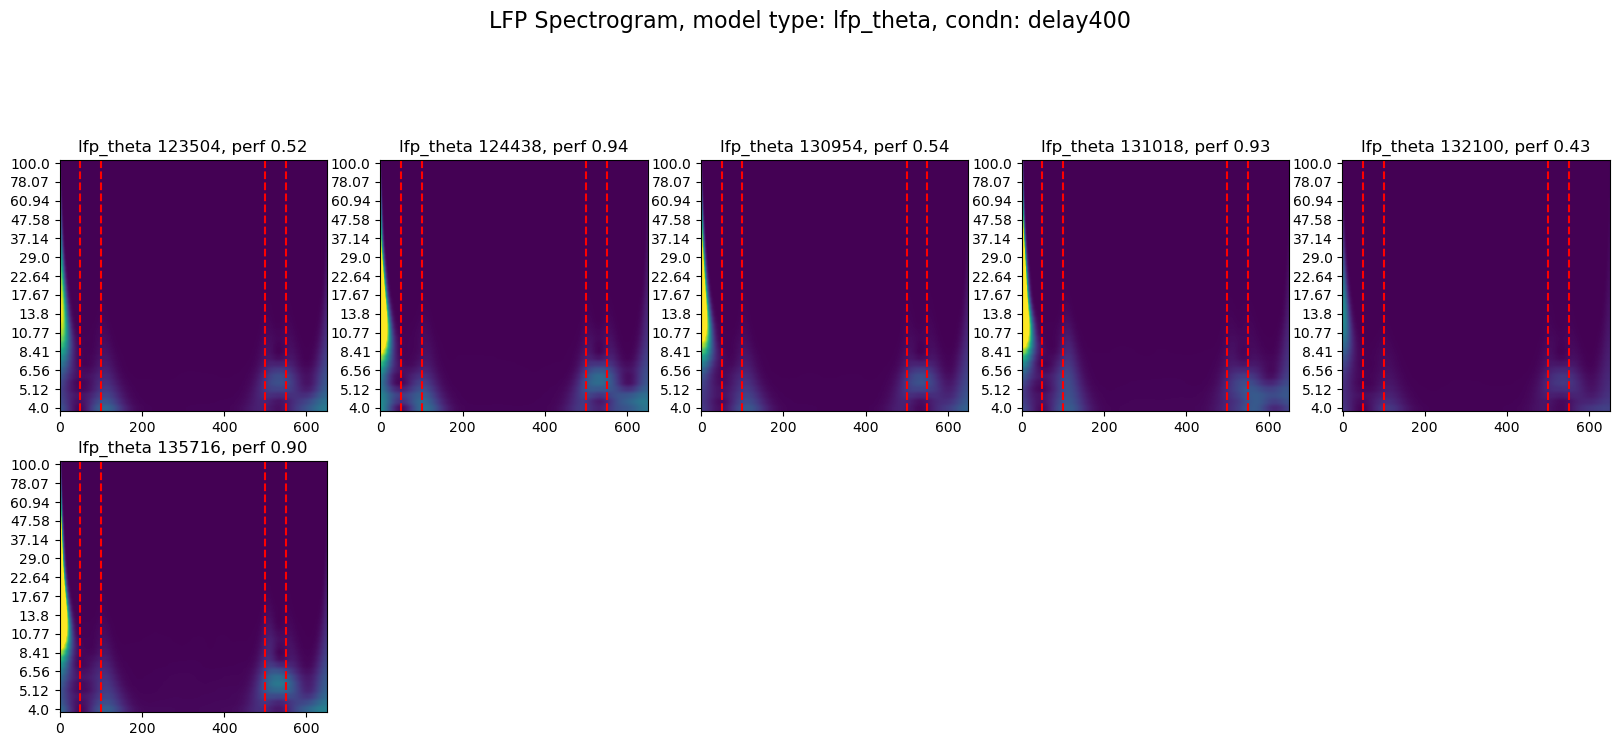

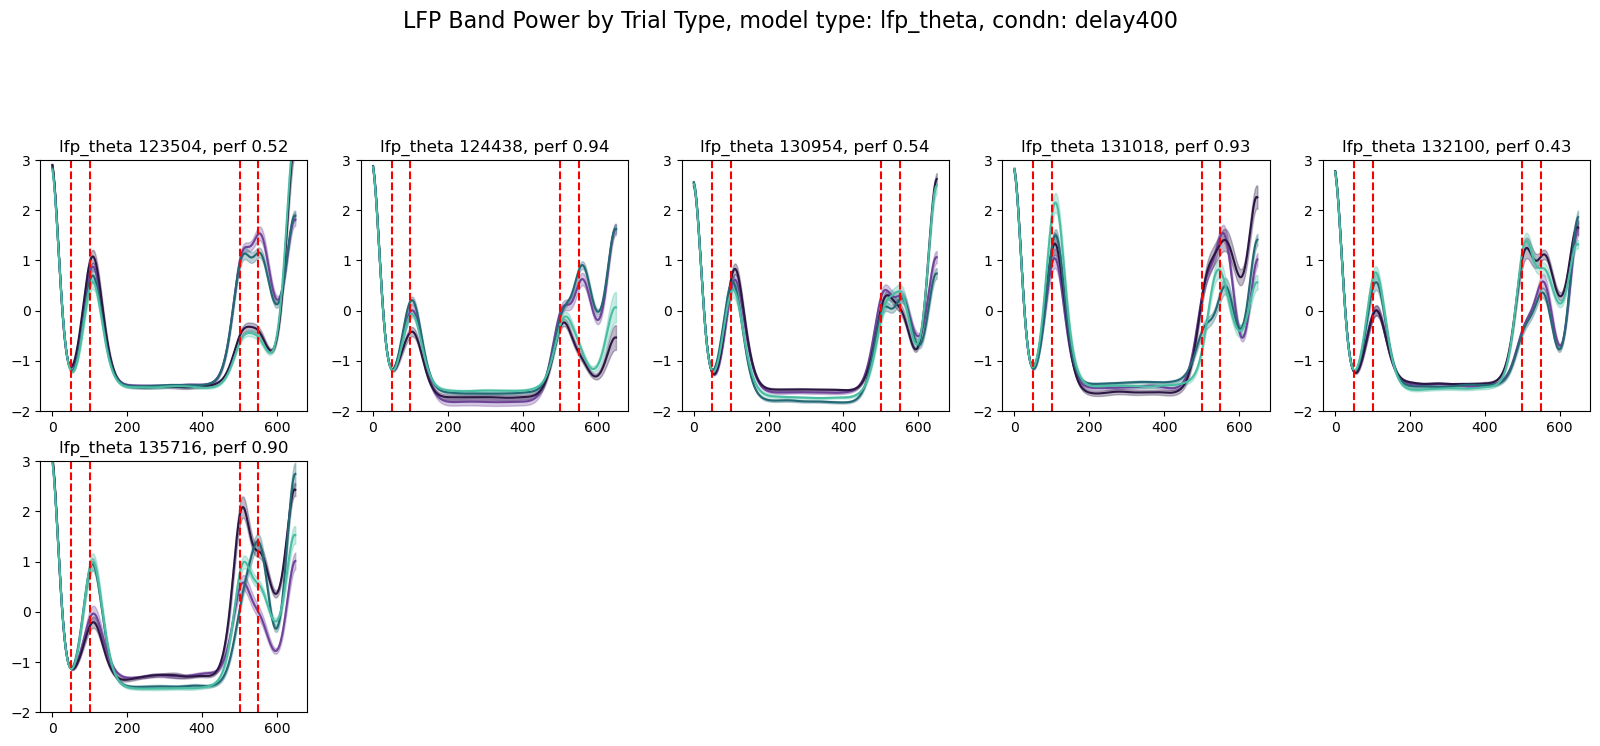

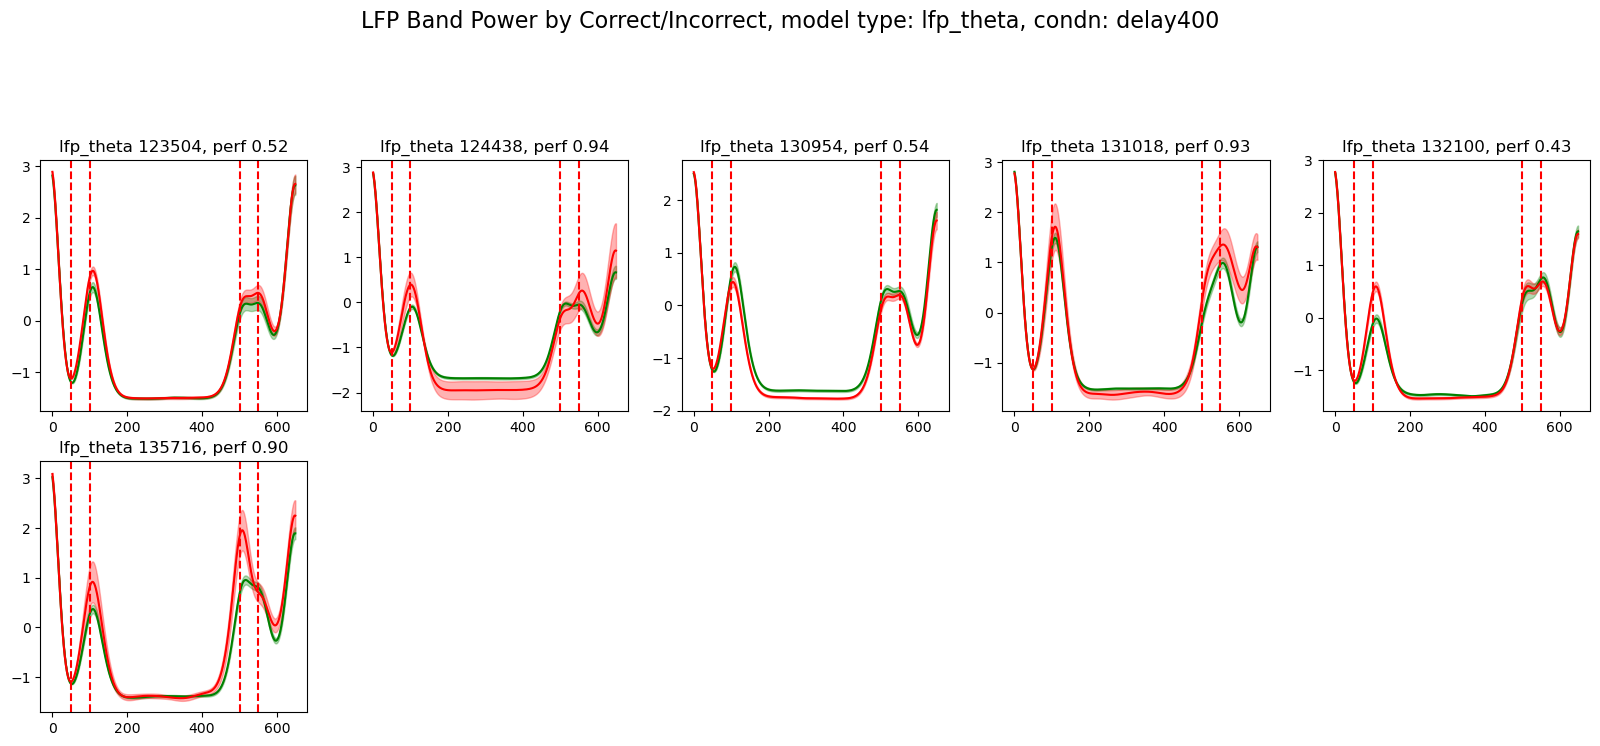

In [9]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect -- NO LESION

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'
condn_name = 'delay400'

print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

# create figure
fig1 = plt.figure(figsize=(20, 15)) # spectrogram
fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    
    # calculate spectrogram data for all trials
    n_freqs = 40
    n_trials = neural_dict['epsp'].shape[0]

    trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
    avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
    for i in range(n_trials):
        trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
        avg_power += trial_power / n_trials
        
    # first plot spectrogram
    ax1 = fig1.add_subplot(4, 5, model_list.index(model_name)+1)
    ax1.imshow(avg_power.T, aspect='auto', origin='lower',
            vmin=0, vmax=1.2)
    ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
    # ax1.colorbar(label='Power')
    ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax1.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    # then plot band power, split by trial type
    ax2 = fig2.add_subplot(4, 5, model_list.index(model_name)+1)
    stims, colors = ld.get_trialtype_colors()
    trial_types, trial_idxs = np.unique(np.array(bhv_dict['trial_type']), axis=0, return_inverse=True)
    for i, trial_type in enumerate(trial_types):
        trials_idx = (trial_idxs == i)
        powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
        powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
        ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
        ax2.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
    ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax2.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    ax2.set_ylim([-2, 3])
    
    # finally plot band power, split by correct/incorrect
    ax3 = fig3.add_subplot(4, 5, model_list.index(model_name)+1)
    correct_trials = (np.array(bhv_dict['perf']) == 1)
    incorrect_trials = (np.array(bhv_dict['perf']) == 0)
    powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
    ax3.plot(powerband_mean, color='g', label='correct')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
    powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
    ax3.plot(powerband_mean, color='r', label='incorrect')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
    ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax3.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')

fig1.suptitle(f'LFP Spectrogram, model type: {model_list_name}, condn: {condn_name}', fontsize=16)
fig2.suptitle(f'LFP Band Power by Trial Type, model type: {model_list_name}, condn: {condn_name}', fontsize=16)
fig3.suptitle(f'LFP Band Power by Correct/Incorrect, model type: {model_list_name}, condn: {condn_name}', fontsize=16)
